In [3]:
import cv2
import numpy as np

# Step 1: Create a canvas with two overlapping circles
img = np.zeros((300, 500), dtype=np.uint8)
cv2.circle(img, (200, 150), 80, 255, -1)
cv2.circle(img, (300, 150), 80, 255, -1)  # Overlaps with first circle

# Step 2: Compute Euclidean Distance Transform
dist = cv2.distanceTransform(img, cv2.DIST_L2, 5)

# Step 3: Normalize distance map to range [0, 255] for visual display
dist_visual = cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Step 4: Threshold distance map to find true object centers (seeds)
_, sure_fg = cv2.threshold(dist, 0.7 * dist.max(), 255, cv2.THRESH_BINARY)
sure_fg = sure_fg.astype(np.uint8)

cv2.imshow("1. Overlapping Binary Circles", img)
cv2.imshow("2. Distance Transform Map", dist_visual)
cv2.imshow("3. Isolated Object Seeds (Sure Foreground)", sure_fg)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [5]:
def segment_and_count_objects(image_path):
    # Step 1: Load image
    img = cv2.imread(image_path)
    if img is None:
        # Create synthetic overlapping circles image if no file provided
        img = np.zeros((400, 600, 3), dtype=np.uint8)
        img[:] = (240, 240, 240)
        # Draw 3 touching/overlapping coins
        cv2.circle(img, (200, 200), 70, (50, 50, 50), -1)
        cv2.circle(img, (290, 200), 70, (50, 50, 50), -1)
        cv2.circle(img, (245, 290), 70, (50, 50, 50), -1)

    # Step 2: Preprocessing (Grayscale + Otsu's Thresholding)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Step 3: Remove small background noise using Morphological Opening
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # Step 4: Determine Sure Background area using Dilation
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # Step 5: Determine Sure Foreground area using Distance Transform
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    # Step 6: Find Unknown Region (Pixels where we are unsure if background or foreground)
    unknown = cv2.subtract(sure_bg, sure_fg)

    # Step 7: Marker Labeling for Watershed
    # Connected components labels sure foreground seeds with 1, 2, 3...
    ret, markers = cv2.connectedComponents(sure_fg)

    # Add 1 to all labels so that background is 1 instead of 0
    markers = markers + 1

    # Mark the unknown region with 0
    markers[unknown == 255] = 0

    # Step 8: Apply Watershed
    markers = cv2.watershed(img, markers)

    # Boundaries are marked with -1
    output_img = img.copy()
    output_img[markers == -1] = [0, 0, 255]  # Red boundary lines

    # Step 9: Count objects (ret includes background label, so total objects = ret - 1)
    total_objects = ret - 1
    print(f"Total Individual Objects Detected: {total_objects}")

    # Annotate total count on output image
    cv2.putText(output_img, f"Total Count: {total_objects}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 150, 0), 2)

    # Display Intermediate & Final Outputs
    cv2.imshow("1. Input Image", img)
    cv2.imshow("2. Thresholded Mask", thresh)
    cv2.imshow("3. Distance Transform Seeds", sure_fg)
    cv2.imshow("4. Watershed Segmented Boundaries", output_img)

    cv2.waitKey(0)
    cv2.destroyAllWindows()

# Run Project
segment_and_count_objects("coin3.webp")

Total Individual Objects Detected: 1


In [7]:
import matplotlib.pyplot as plt

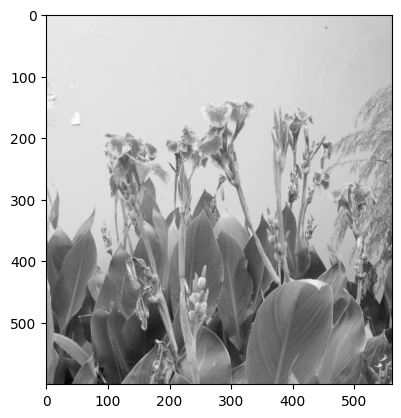

In [9]:
flowers = cv2.imread("flower a1 copy.jpeg")
flowers_gray = cv2.cvtColor(flowers, cv2.COLOR_BGR2GRAY)
plt.imshow(flowers_gray, cmap = 'gray')

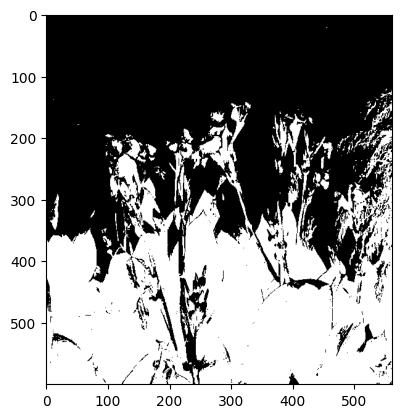

In [13]:
_, thresh = cv2.threshold(flowers_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.imshow(thresh, cmap = 'gray')

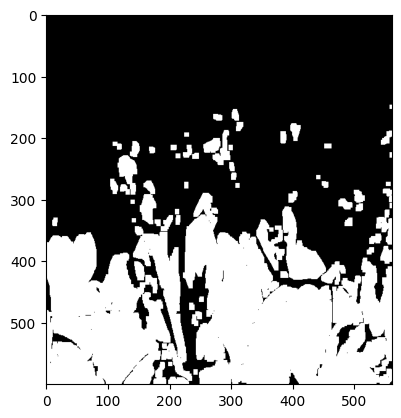

In [19]:
kernel = np.ones((3, 3), dtype = 'uint8')
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations = 3)
plt.imshow(opening, cmap = 'gray')

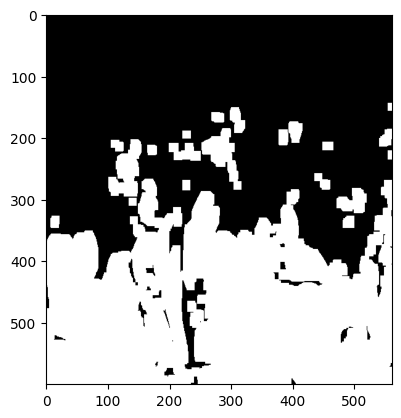

In [21]:
sure_bg =  cv2.dilate(opening, kernel, iterations = 3)
plt.imshow(sure_bg, cmap = 'gray')

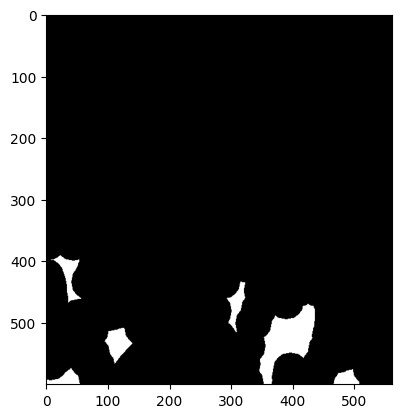

In [23]:
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
plt.imshow(sure_fg, cmap = 'gray')

In [25]:
print(sure_bg.dtype)
print(sure_fg.dtype)

print(sure_bg.shape)
print(sure_fg.shape)

uint8
uint8
(600, 561)
(600, 561)


In [27]:
unknown = cv2.subtract(sure_bg, sure_fg)

In [31]:
ret, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown == 255] = 0

markers = cv2.watershed(flowers, markers)

In [35]:
print(flowers.dtype, flowers.shape)
print(markers.dtype, markers.shape)

uint8 (600, 561, 3)
int32 (600, 561)


In [37]:
output_img = flowers.copy()
output_img[markers == -1] = [0, 0, 255]

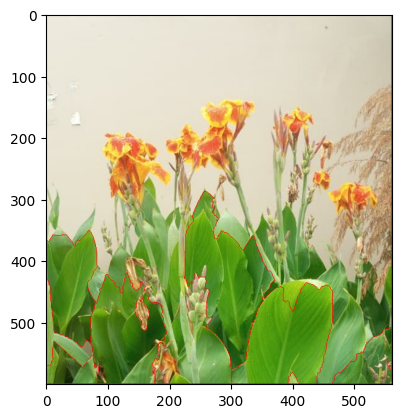

In [39]:
plt.imshow(output_img[:,:,::-1])

In [41]:
from PIL import Image

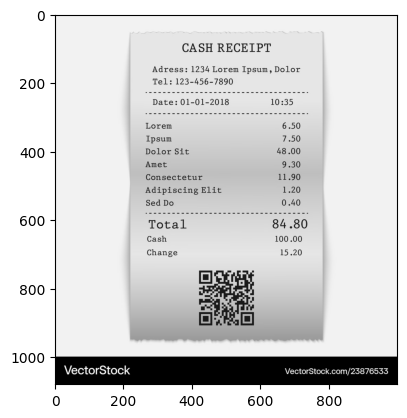

In [43]:
pil_image = Image.open("receipt.avif")
receipt = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
plt.imshow(receipt)

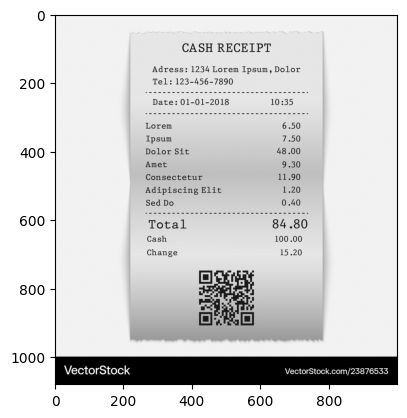

In [45]:
receipt_gray = cv2.cvtColor(receipt, cv2.COLOR_BGR2GRAY)
plt.imshow(receipt_gray, cmap = 'gray')

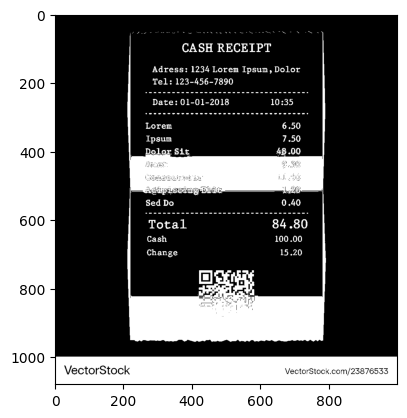

In [46]:
_, thresh = cv2.threshold(receipt_gray, 200, 255, cv2.THRESH_BINARY_INV)
plt.imshow(thresh, cmap = 'gray')

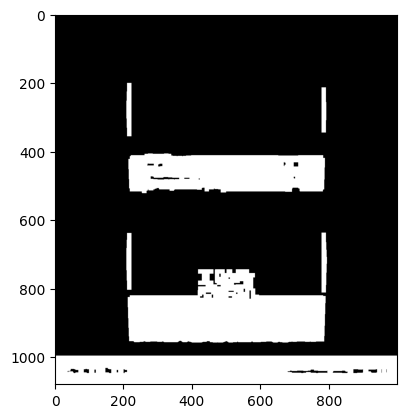

In [48]:
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations = 3)

sure_bg = cv2.dilate(opening, kernel, iterations = 3)
plt.imshow(sure_bg, cmap='gray')

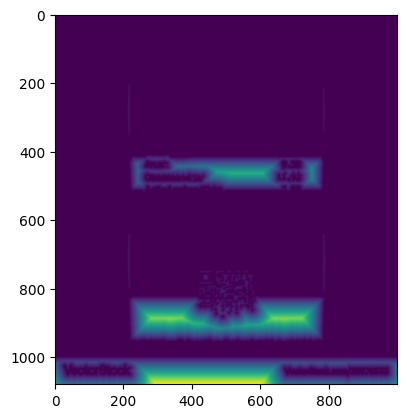

In [50]:
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
plt.imshow(dist_transform)

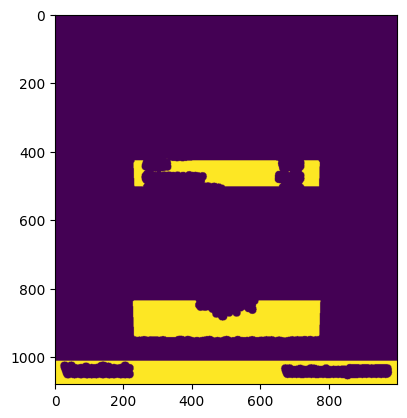

In [52]:
_, sure_fg = cv2.threshold(dist_transform, 12, 255, 0)
sure_fg = np.uint8(sure_fg)
plt.imshow(sure_fg)

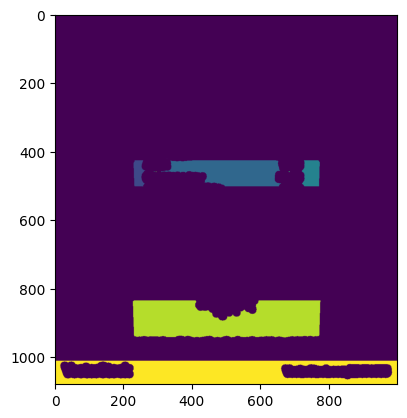

In [54]:
unknown = cv2.subtract(sure_bg, sure_fg)

ret, markers = cv2.connectedComponents(sure_fg)
plt.imshow(markers)

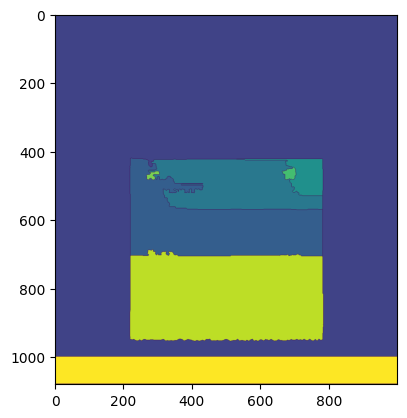

In [55]:
makers = markers + 1
markers[unknown == 255] = 0
markers = cv2.watershed(receipt, markers)
plt.imshow(markers)

In [57]:
receipt[markers== -1] = [0, 0, 255]
cv2.imshow("Objects",receipt)
cv2.waitKey(0)
cv2.destroyAllWindows()

### From youtube

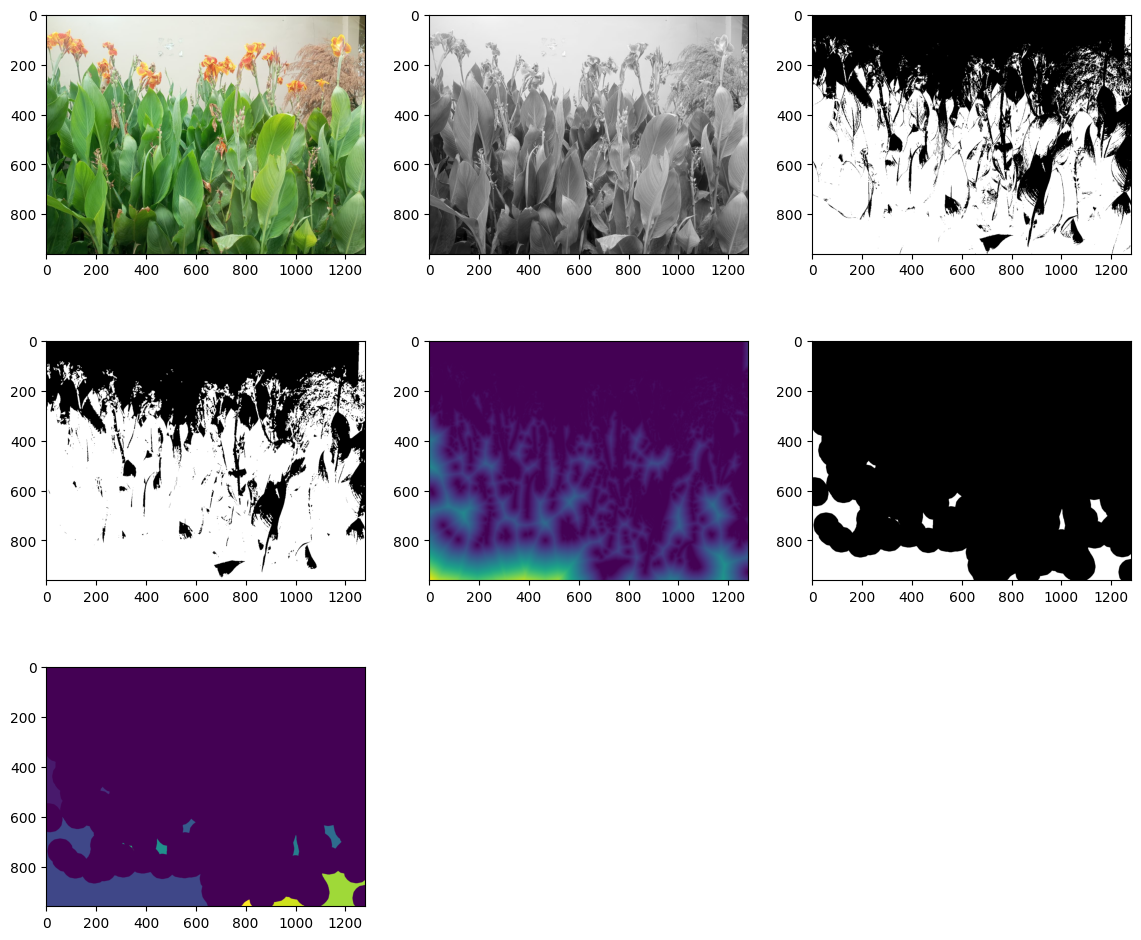

In [62]:
flowers = cv2.imread("flower a3.jpeg")

plt.figure(figsize = (14,12))
flowersRGB = cv2.cvtColor(flowers, cv2.COLOR_BGR2RGB)
plt.subplot(3, 3, 1)
plt.imshow(flowersRGB)

flowers_gray = cv2.cvtColor(flowers, cv2.COLOR_BGR2GRAY)
plt.subplot(3, 3, 2)
plt.imshow(flowers_gray, cmap = 'gray')

_, flowers_thresh = cv2.threshold(flowers_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.subplot(3, 3, 3)
plt.imshow(flowers_thresh, cmap = 'gray')

kernel = np.ones((3, 3), np.uint8)
flowersDilate = cv2.morphologyEx(flowers_thresh, cv2.MORPH_DILATE, kernel)
plt.subplot(3, 3, 4)
plt.imshow(flowersDilate, cmap = 'gray')

distTrans = cv2.distanceTransform(flowersDilate, cv2.DIST_L2, 5)
plt.subplot(3, 3, 5)
plt.imshow(distTrans)

distTrans = np.uint8(distTrans)
_, distThresh = cv2.threshold(distTrans, 50, 255, cv2.THRESH_BINARY)
plt.subplot(3, 3, 6)
plt.imshow(distThresh, cmap = 'gray')

distThresh = np.uint8(distThresh)
_, labels = cv2.connectedComponents(distThresh)
plt.subplot(3, 3, 7)
plt.imshow(labels)

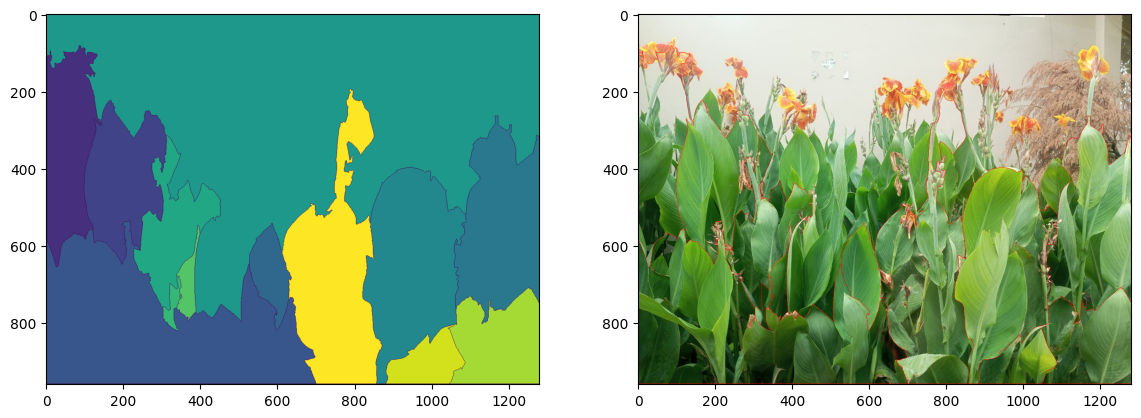

In [63]:
plt.figure(figsize = (14, 7))

labels = np.int32(labels)
labels = cv2.watershed(flowersRGB, labels)
plt.subplot(1, 2, 1)
plt.imshow(labels)

plt.subplot(1, 2, 2)
flowersRGB[labels == -1] = [255, 0, 0]
plt.imshow(flowersRGB)